In [1]:
#Load Packages
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod import families
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

#Load Data
project_root = Path.cwd().parent
data_file = project_root / "covid_cases.csv"
casedata = pd.read_csv(data_file)
print(casedata.shape[0])

1275


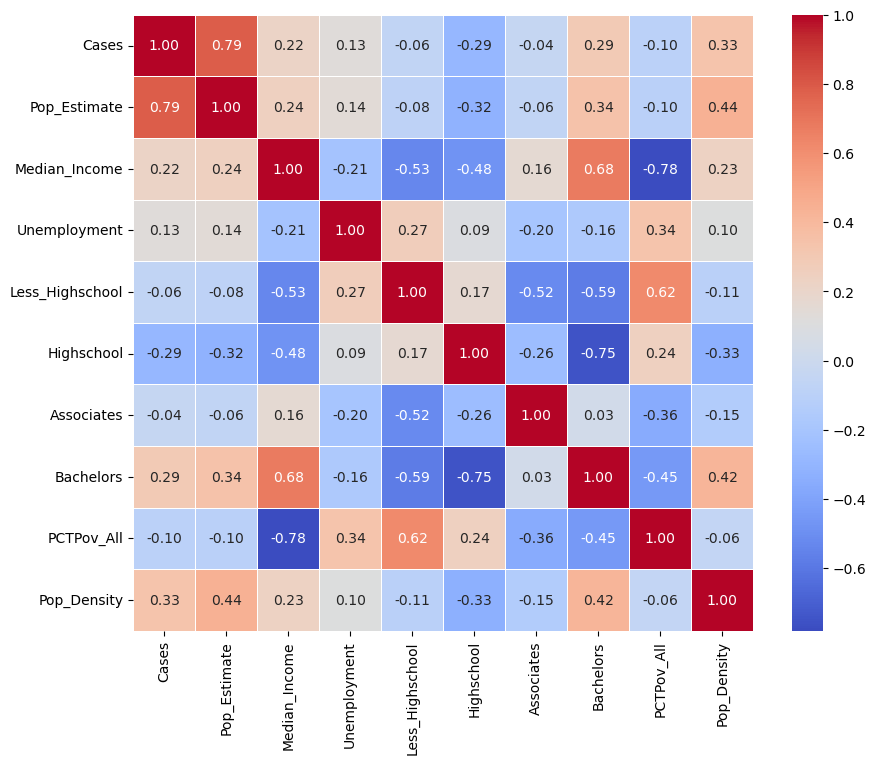

In [2]:
#Correlation Plot for numerical data
correlation_matrix = casedata.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

We have a large correlation between the number of cases and the county population, which is expected since the population count is used to obtain the rate of cases per population unit. Some large correlation between some of the explanatory factors, for example, population density and population count, as well as between Median Income and percentage of people with a bachelor’s degree.

In [3]:
# Linear model with response Cases/Population
casedata['Response'] = casedata['Cases'] / casedata['Pop_Estimate']

# Remove Pop_Estimate column & Replace Response
casedata_lm = casedata.copy()
casedata_lm.drop('Pop_Estimate', axis=1, inplace=True)

# Linear model
x = sm.add_constant(casedata_lm.drop(['Cases','Response'], axis=1))
y = casedata_lm['Response']
linear_model = sm.OLS(y, x).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Response   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.722
Date:                Thu, 22 May 2025   Prob (F-statistic):             0.0890
Time:                        22:56:02   Log-Likelihood:                 560.56
No. Observations:                1275   AIC:                            -1103.
Df Residuals:                    1266   BIC:                            -1057.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.6317      7.499     

For the linear model, the response is the ratio between the number of cases and the population within each county to model the rate of cases rather than the number of cases. In order to use the simple approach for modeling all predicting variables without their specification, we need to revise the data matrix used as input to discard the Population Estimate column, which is used to derive the response variable.

The p-values for the statistical significance of the regression coefficients are all large, indicating that none of the regression coefficient is statistically significant. Moreover, the R-squared is 0.0107, meaning that only 1.07% of the variability is explained but the predicting factors included in the model. Similarly, the overall regression is not statistically significant.

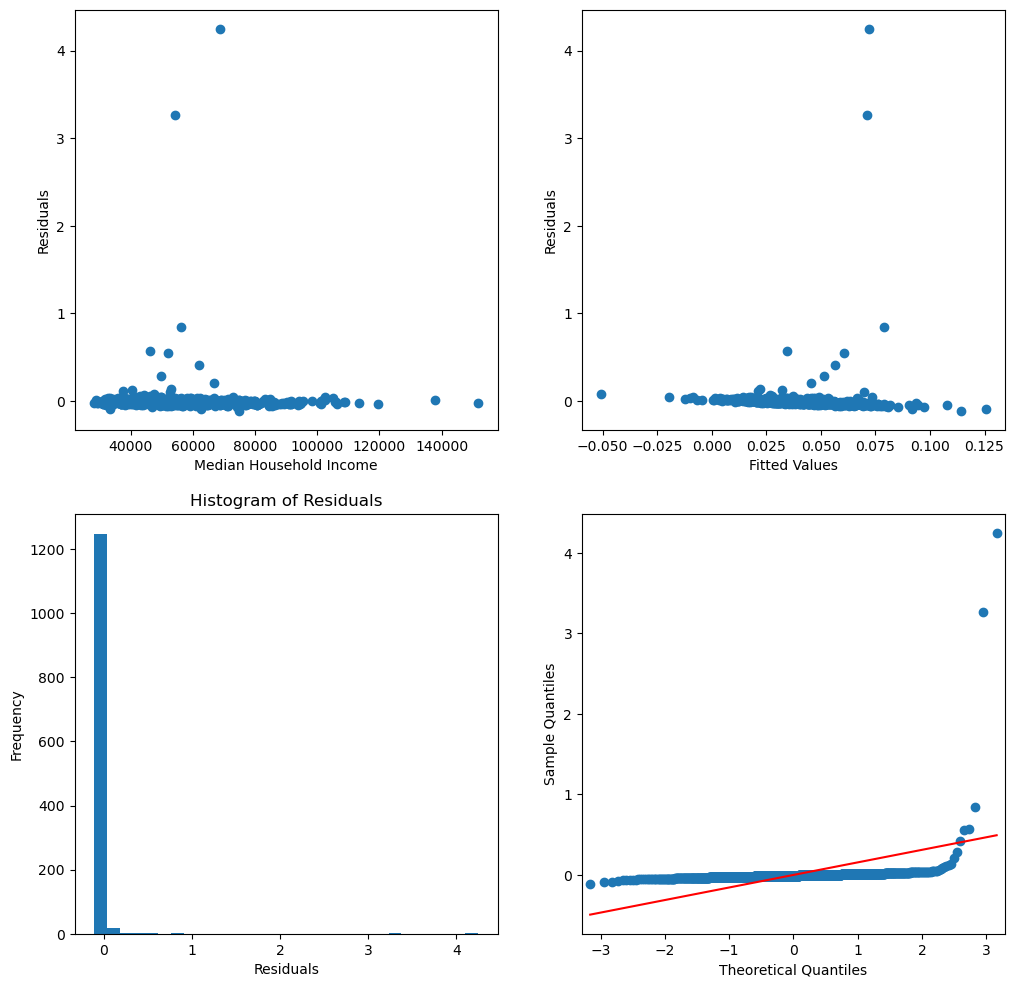

In [4]:
##Residual Analysis
res = linear_model.resid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axes[0, 0].scatter(casedata['Median_Income'], res)
axes[0, 0].set(xlabel='Median Household Income', ylabel='Residuals')
axes[0, 1].scatter(linear_model.fittedvalues, res)
axes[0, 1].set(xlabel='Fitted Values', ylabel='Residuals')
axes[1, 0].hist(res, bins=30)
axes[1, 0].set(xlabel='Residuals', ylabel='Frequency', title="Histogram of Residuals")
sm.qqplot(res, line='s', ax=axes[1, 1])
plt.show()

A series of outliers show in the scatterplots, making it hard to evaluate the goodness of fit of the model.

In [5]:
#Poission model with offset
offset = np.log(casedata['Pop_Estimate'])
poisson_model = sm.GLM(casedata['Cases'], x, offset=offset, family=sm.families.Poisson()).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Cases   No. Observations:                 1275
Model:                            GLM   Df Residuals:                     1266
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1328e+06
Date:                Thu, 22 May 2025   Deviance:                   2.2548e+06
Time:                        22:56:03   Pearson chi2:                 2.18e+07
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              36.7367      0.828     

We use the Population Estimate as an offset.

For the Poisson Regression model, all regression coefficients are statistically significant as the p-values are very small.

We interprete one coefficient as an example. The coefficient corresponding to the predicting variable corresponding to the percentage of people with high school only for their education which is equal to −0.4213. This can be interpreted as follows: for one unit increase in the percentage of individuals with high school education only, the log expected case count decreases by 0.4213, holding everything else fixed, OR the rate ratio for cases would be expected to decrease by a factor of exp(0.4213)=1.524, holding everything else fixed.

In [6]:
#Test for overall regression
# Given values
null_deviance = poisson_model.null_deviance
model_deviance = poisson_model.deviance
df_model = poisson_model.df_model

# test statistic
test_statistic = null_deviance - model_deviance

# p-value
p_value = 1 - chi2.cdf(test_statistic, df_model)

print(f"Likelihood Ratio Test p-value: {p_value}")

Likelihood Ratio Test p-value: 0.0


The test value is the difference between the null deviance and the residual deviance provided and the degree of freedom is eight since we have eight predicting variables. We compute the p-value of the test using the chi-squared distribution with eight degrees of freedom. This can be implemented using the pchisq command and it returns the left tail. However, we need the RIGHT or the upper tail, we will take one minus this probability to get the p-value.

The p-value of this test is approximately zero, thus the overall regression is statistically significant.

In [7]:
#Goodness of Fit Test
print(f"Residual Deviance: {round(poisson_model.deviance,4)}")
print(f"Degrees of Freedom: {len(casedata) - len(x.columns)}")
print(f"p-value: {chi2.sf(poisson_model.deviance, len(casedata) - len(x.columns))}")

Residual Deviance: 2254848.9655
Degrees of Freedom: 1266
p-value: 0.0


The code above use deviance test to apply the goodness-of-fit test and it returns the p-value by pchisq(). We take one minus the probability to get the upper tail.

The p-value is approximately zero, meaning we reject the null hypothesis of good fit.

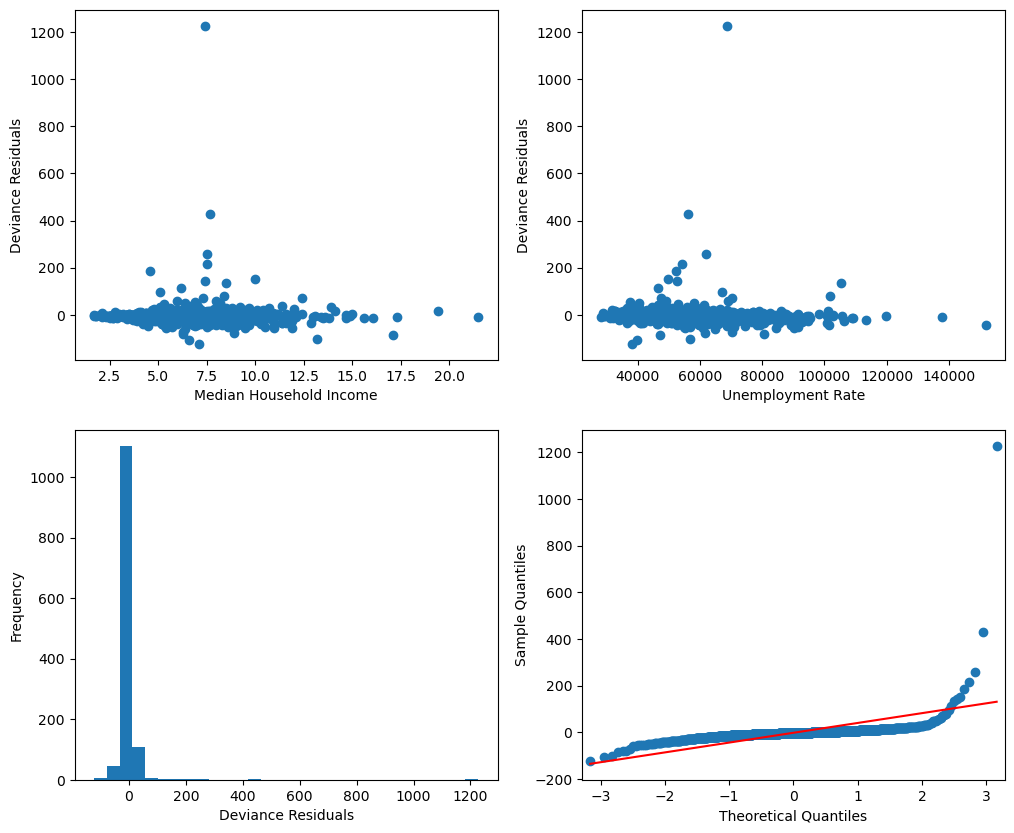

In [8]:
#Residual Analysis
dev_residuals = poisson_model.resid_deviance
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes[0, 0].scatter(casedata['Unemployment'], dev_residuals)
axes[0, 0].set(xlabel='Median Household Income', ylabel='Deviance Residuals')
axes[0, 1].scatter(casedata['Median_Income'], dev_residuals)
axes[0, 1].set(xlabel='Unemployment Rate', ylabel='Deviance Residuals')
axes[1, 0].hist(dev_residuals, bins=30)
axes[1, 0].set(xlabel='Deviance Residuals', ylabel='Frequency')
sm.qqplot(dev_residuals, line='s', ax=axes[1, 1])
plt.show()

A series of outliers are in the scatterplots, making it hard to evaluate goodness of fit of the model.

In [9]:
#Outliers in Poisson Regression
# Outlier detection using Cook's distance
influence = poisson_model.get_influence()
cooks_distance = influence.cooks_distance[0]
outliers_cooks = cooks_distance > 1
print(f"Number of outliers detected by Cook's distance: {sum(outliers_cooks)}")

# Robust Poisson model after removing outliers
casedata_rob = casedata.loc[~outliers_cooks, :]
poisson_model_rob = sm.GLM(casedata_rob['Cases'], x.iloc[~outliers_cooks, :], offset=np.log(casedata_rob['Pop_Estimate']), family=sm.families.Poisson()).fit()
deviance = poisson_model_rob.deviance
df_residual = poisson_model_rob.df_resid
# Calculate the p-value for the deviance
p_value = 1 - chi2.cdf(deviance, df_residual)
print(round(deviance,4), df_residual, p_value)

Number of outliers detected by Cook's distance: 93
128977.809 1173 0.0


We use deviance residual for this case. It returns 93 outliers out of 1275 observations. If we identify such a large number, it may actually be that the distribution of the residuals is heavy tailed not because of outliers but because of the lack of fit.

We refitted the model without the 93 outliers and perform the deviance test again. The p-value is still approximate zero which indicates it does not have a good fit.

However, Cook’s Distance is not appropriate to be used for a generalized linear model since it is defined and computed assuming the residuals are from a multiple linear regression model and suggest not using this approach for Poisson regression or logistice regression.

Discussion: 

While Cook's distance can be applied in Python to the residuals of Poisson regression, it is not an appropriate (correct) approach for Poisson regression since its computation assumes that the residuals came from a multiple linear regression, which is not quite the same to Poisson regression. Then what approaches are there?

In [10]:
## Assuming GOF: Deviance ~ N(0,1)
##  Evaluate Deviance residuals vs the Normal quantile with prob=0.99995
outliers = dev_residuals[abs(dev_residuals) > norm.ppf(.99995)]
print(len(outliers))

881


Discussion:

Assuming goodness of fit (Deviance coming from a N(0,1) ) and comparing residuals vs the quantile of the 0.99995 tail means that the probability of a residual to be larger than this quantile is 0.00001, which is a very small probability. However, this rule would identify 881 observations to be outliers. This is an indication that the residuals have a heavy-tail distribution, hence Poisson regression is not appropriate, indicating a model with overdisperion.

In [11]:
#Do we have overdispersion?
wdf = len(casedata) - len(x.columns)
dev = poisson_model.deviance
overdisp = dev/wdf
print(round(overdisp,4))

1781.0813


The overdispersion parameter is larger than threshold 2. We need to apply an overdispersion adjustment model.

### Quasi Poisson Model

In [12]:
offset = np.log(casedata['Pop_Estimate'])
X = casedata.drop(['Cases','Pop_Estimate',"Response"], axis=1)
X = sm.add_constant(X)  
y = casedata['Cases']

# Fit the model with the quasi-Poisson adjustment by specifying the scale
quasi_poisson_model = sm.GLM(y, X, family=sm.families.Poisson(), offset=offset).fit(scale='X2')

print(quasi_poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Cases   No. Observations:                 1275
Model:                            GLM   Df Residuals:                     1266
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          17193.
Method:                          IRLS   Log-Likelihood:                -65.886
Date:                Thu, 22 May 2025   Deviance:                   2.2548e+06
Time:                        22:56:03   Pearson chi2:                 2.18e+07
No. Iterations:                     8   Pseudo R-squ. (CS):           0.004571
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              36.7367    108.631     

Quasi Poisson model applied here allows for multiplicative factor added to the variance to avoid overdispersion.

Comparing with Poisson Regression model, all the coefficient estimates are the same because Quasi poisson model only impact variance. Hence, the statistical significance for the regression coefficients are different. In Poisson regression, all coefficients are statistically significant however none of the coefficients are statistically significant in Quasi Poisson regression model.

# Negative Binomial Model

In [13]:
# Response = Cases in Negative Binomial but include Offset as predictor
offset = np.log(casedata['Pop_Estimate'])
X_nb = casedata.drop(['Cases', "Response"], axis=1)
X_nb = sm.add_constant(X_nb)  
y_nb = casedata['Cases']

# Alpha equals 1/theta (get theta from R) 
model_nb = sm.GLM(y_nb, X_nb, family=sm.families.NegativeBinomial(alpha=0.9366)).fit()

print(model_nb.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Cases   No. Observations:                 1275
Model:                            GLM   Df Residuals:                     1265
Model Family:        NegativeBinomial   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10354.
Date:                Thu, 22 May 2025   Deviance:                       1462.5
Time:                        22:56:03   Pearson chi2:                 3.60e+03
No. Iterations:                    51   Pseudo R-squ. (CS):             0.8404
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              78.3011     46.433     

The Negative Binomial model is another way to adjust for overdispersion. In this model, we include Population Estimate as a controlling factor. Coefficients, Pop Estimate, Unemployment rate, Percent of Population under the Poverty level and Population Density, are statistically significant.